# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, subprocess
import numpy as np, pandas as pd, torch
from IPython.display import display
import torch.nn as nn
import torch.nn.functional as F

MSSV = "2A202602451"
REPO_URL = "https://github.com/SxAinsworth/K4-Track4-Day1-Neuralnetwork.git"   # fork của mình (có code đã push)
IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")

if IN_COLAB:
    # Kernel Colab (kể cả khi mở từ VS Code) chạy trên máy chủ: lấy code + dữ liệu bằng git,
    # rồi chuyển cwd vào submission_<MSSV>/code để mọi đường dẫn tương đối giống hệt khi chạy local.
    COLAB_REPO = "/content/K4-Track4-Day1-Neuralnetwork"
    if not os.path.isdir(COLAB_REPO):
        subprocess.run(["git", "clone", REPO_URL, COLAB_REPO], check=True)
    else:
        subprocess.run(["git", "-C", COLAB_REPO, "pull", "--ff-only"], check=True)
    os.chdir(f"{COLAB_REPO}/submission_{MSSV}/code")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

REPO_ROOT = "../.."     # gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # submission_<MSSV>/: nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

os.makedirs(os.path.join(OUT_DIR, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "results"), exist_ok=True)

# Kiểm tra trước khi đọc dữ liệu: repo phải chứa data/ và kết quả phải nằm trong thư mục nộp.
repo_root_abs = os.path.abspath(REPO_ROOT)
out_dir_abs = os.path.abspath(OUT_DIR)
print(f"REPO_ROOT -> {repo_root_abs}")
print(f"OUT_DIR   -> {out_dir_abs}")
assert os.path.isdir(os.path.join(repo_root_abs, "data")), "REPO_ROOT không trỏ tới gốc repo có data/."
assert os.path.basename(out_dir_abs) == f"submission_{MSSV}", "OUT_DIR không trỏ tới thư mục nộp."


def push_outputs(msg="Update results from Colab"):
    """Đẩy figures/, results/, xlsx, csv, json từ runtime Colab về GitHub (máy local chỉ cần git pull).
    Cần GitHub token (fine-grained, quyền Contents: read/write trên repo fork); token không được lưu vào notebook."""
    if not IN_COLAB:
        print("Đang chạy local: kết quả đã nằm sẵn trên máy, không cần push.")
        return
    from getpass import getpass
    token = os.environ.get("GH_TOKEN") or getpass("GitHub token: ")
    os.environ["GH_TOKEN"] = token                      # chỉ giữ trong phiên runtime hiện tại
    git = ["git", "-C", COLAB_REPO, "-c", "user.name=SxAinsworth",
           "-c", "user.email=SxAinsworth@users.noreply.github.com"]
    subprocess.run(git + ["add", f"submission_{MSSV}"], check=True)
    if subprocess.run(git + ["diff", "--cached", "--quiet"]).returncode == 0:
        print("Không có gì mới để push.")
        return
    subprocess.run(git + ["commit", "-q", "-m", msg], check=True)
    url = REPO_URL.replace("https://", f"https://x-access-token:{token}@")
    subprocess.run(git + ["pull", "--rebase", "-q", url, "main"], check=True)
    subprocess.run(git + ["push", "-q", url, "HEAD:main"], check=True)
    print("Đã push. Trên máy local chạy: git pull")


from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4
REPO_ROOT -> /content/K4-Track4-Day1-Neuralnetwork
OUT_DIR   -> /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602451


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# Chia train/eval theo metadata (chỉ chạy script nếu chưa có file .npz)
if not os.path.exists(f"{REPO_ROOT}/data/processed/eval.npz"):
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

set_seed(42)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert len(data["X_tr"]) == 371_847 and len(data["X_val"]) == 92_962 and len(data["X_eval"]) == 116_203

# Tỉ lệ lớp ở 3 tập phải gần như bằng nhau (phân tầng)
print("\nlớp   train(%)   val(%)   eval(%)")
props = [torch.bincount(data[k], minlength=7).float().cpu() / len(data[k]) * 100 for k in ("y_tr", "y_val", "y_eval")]
for c in range(7):
    print(f"{c:>3d}   {props[0][c]:7.3f}  {props[1][c]:7.3f}  {props[2][c]:7.3f}")

# 10 cột số trên X_tr sau chuẩn hoá: mean ≈ 0, std ≈ 1; 44 cột nhị phân giữ nguyên 0/1
num = data["X_tr"][:, :10]
print("\nmean 10 cột số (X_tr):", np.round(num.mean(0).cpu().numpy(), 4))
print("std  10 cột số (X_tr):", np.round(num.std(0).cpu().numpy(), 4))
print("cột nhị phân chỉ gồm 0/1:", bool(torch.isin(data["X_tr"][:, 10:], torch.tensor([0.0, 1.0], device=device)).all()))

train (371847, 54) | val (92962, 54) | eval (116203, 54)
luôn đoán lớp đa số (1): val acc = 0.4876

lớp   train(%)   val(%)   eval(%)
  0    36.461   36.460   36.460
  1    48.760   48.760   48.760
  2     6.154    6.154    6.154
  3     0.473    0.472    0.472
  4     1.634    1.634    1.634
  5     2.989    2.989    2.989
  6     3.530    3.530    3.530

mean 10 cột số (X_tr): [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  10 cột số (X_tr): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
cột nhị phân chỉ gồm 0/1: True


In [3]:
# Kiểu dữ liệu và khoảng nhãn của các tensor dùng chung cho mọi thí nghiệm
for k in ("X_tr", "y_tr", "X_val", "y_val", "X_eval", "y_eval"):
    t = data[k]
    extra_info = f"nhãn {t.min().item()}..{t.max().item()}" if k.startswith("y") else ""
    print(f"{k:<7s} {str(tuple(t.shape)):<12s} {str(t.dtype):<14s} {t.device}  {extra_info}")
assert all(data[k].dtype == torch.float32 and data[k].shape[1] == 54 for k in ("X_tr", "X_val", "X_eval"))
assert all(data[k].dtype == torch.int64 for k in ("y_tr", "y_val", "y_eval"))

# eval_row_id phải gắn đúng thứ tự mẫu eval: đủ 116 203 id, không trùng, và đối chiếu ngẫu nhiên vài dòng với CSV gốc
import pandas as pd
rid = data["eval_row_id"]
assert len(rid) == len(data["X_eval"]) == 116_203 and len(np.unique(rid)) == len(rid)
raw = pd.read_csv(f"{REPO_ROOT}/data/covtype.csv.gz")
check = np.random.default_rng(0).choice(len(rid), size=200, replace=False)
csv_rows = raw.iloc[rid[check]]
X_eval_raw = csv_rows.drop(columns="Cover_Type").to_numpy(np.float32)
X_eval_back = data["X_eval"][check].cpu().numpy().copy()
X_eval_back[:, :10] = X_eval_back[:, :10] * np.where(data["std"] > 0, data["std"], 1) + data["mean"]   # bỏ chuẩn hoá
assert np.allclose(X_eval_back, X_eval_raw, atol=1e-2), "X_eval lệch với CSV theo row_id"
assert (csv_rows["Cover_Type"].to_numpy() - 1 == data["y_eval"][check].cpu().numpy()).all(), "nhãn eval lệch với CSV"
print("eval_row_id: 200 dòng ngẫu nhiên khớp CSV gốc (đặc trưng và nhãn) ✓")
del raw

# iterate_batches: mỗi epoch đi qua MỌI mẫu train đúng một lần; lô cuối nhỏ hơn được giữ lại
sizes, seen = [], []
g = torch.Generator().manual_seed(0)
for xb, yb in iterate_batches(data["X_tr"], data["y_tr"], 512, generator=g):
    sizes.append(len(xb))
print(f"batch 512: {len(sizes)} lô/epoch, lô cuối = {sizes[-1]} mẫu, tổng = {sum(sizes)}")
assert sum(sizes) == len(data["X_tr"]) and sizes[-1] == len(data["X_tr"]) % 512

X_tr    (371847, 54) torch.float32  cuda:0  
y_tr    (371847,)    torch.int64    cuda:0  nhãn 0..6
X_val   (92962, 54)  torch.float32  cuda:0  
y_val   (92962,)     torch.int64    cuda:0  nhãn 0..6
X_eval  (116203, 54) torch.float32  cuda:0  
y_eval  (116203,)    torch.int64    cuda:0  nhãn 0..6
eval_row_id: 200 dòng ngẫu nhiên khớp CSV gốc (đặc trưng và nhãn) ✓
batch 512: 727 lô/epoch, lô cuối = 135 mẫu, tổng = 371847


**Nhận xét Part 0:**
- Kích thước khớp GUIDE: train còn 371 847, val 92 962, eval 116 203. Tỉ lệ lớp ở ba tập gần như trùng nhau nhờ phân tầng. Phép tách val dùng **seed 42 cố định** cho mọi thí nghiệm; khi đổi seed huấn luyện để đo nhiễu, seed tách val vẫn giữ nguyên.
- Mốc "luôn đoán lớp đa số" (lớp 1) trên val = 0,4876: mọi mô hình phải vượt mức này.
- **Vì sao chỉ dùng X_tr để tính mean/std?** Mean/std là tham số của pipeline, cũng "học" từ dữ liệu như trọng số. Nếu tính trên val hoặc eval, thông tin của tập dùng để đánh giá rò rỉ vào bước tiền xử lý, nên điểm val/eval không còn là ước lượng trung thực cho dữ liệu chưa thấy. Áp dụng *cùng* mean/std của train lên val/eval thì được phép (giống khi triển khai: dữ liệu mới chỉ được biến đổi bằng thống kê đã có).
- 44 cột nhị phân (Wilderness_Area, Soil_Type) giữ nguyên 0/1; nếu cột số nào có std = 0 thì chỉ trừ mean (tránh chia cho 0).
- **Lô cuối:** 371 847 = 726 × 512 + 135, nên lô cuối có 135 mẫu. Mình giữ lô này (không `drop_last`) để mỗi epoch dùng hết dữ liệu; nó chỉ chiếm 1/727 số bước nên ảnh hưởng không đáng kể.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [4]:
# 1a–1b. Dựng M-base, kiểm tra số tham số và shape qua từng lớp
set_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879, n_params
print(model)
print("số tham số:", n_params)

h = torch.randn(8, 54, device=device)
print(f"\n{'đầu vào':<54s} {tuple(h.shape)}")
for layer in model.net:
    h = layer(h)
    print(f"{str(layer):<54s} {tuple(h.shape)}")
assert h.shape == (8, 7)

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879

đầu vào                                                (8, 54)
Linear(in_features=54, out_features=256, bias=True)    (8, 256)
ReLU()                                                 (8, 256)
Linear(in_features=256, out_features=128, bias=True)   (8, 128)
ReLU()                                                 (8, 128)
Linear(in_features=128, out_features=7, bias=True)     (8, 7)


In [5]:
# 1b (tiếp). Kiểm tra cấu trúc, không chỉ shape
linears = [m for m in model.modules() if isinstance(m, nn.Linear)]
assert [(m.in_features, m.out_features) for m in linears] == [(54, 256), (256, 128), (128, 7)]
assert all(m.bias is not None for m in linears), "mọi Linear phải có bias"
assert isinstance(model.net[-1], nn.Linear), "lớp cuối phải là Linear (logit thô, không softmax)"
assert not any(isinstance(m, (nn.Softmax, nn.LogSoftmax, nn.BatchNorm1d, nn.LayerNorm)) for m in model.modules())
print("Linear:", [(m.in_features, m.out_features) for m in linears], "| bias: có ở mọi lớp | không softmax/BatchNorm/LayerNorm")

# Hai kiến trúc tuỳ chọn cũng phải khớp số tham số quy định
for hid in [(512, 256), (256, 128, 64)]:
    n = count_params(MLP(hidden=hid))
    assert n == EXPECTED_PARAMS[hid], (hid, n)
    print(f"MLP{hid}: {n:,} tham số ✓")

# Dropout (khi q > 0) chỉ nằm ngay sau ReLU của lớp ẩn, không ở đầu vào hay trên logit
m_drop = MLP(hidden=(256, 128), dropout=0.3)
kinds = [type(l).__name__ for l in m_drop.net]
print("q = 0.3:", " → ".join(kinds))
assert kinds == ["Linear", "ReLU", "Dropout", "Linear", "ReLU", "Dropout", "Linear"]
assert all(l.p == 0.3 for l in m_drop.net if isinstance(l, nn.Dropout))

# He thực sự được áp dụng: std(W) ≈ sqrt(2/n_in), bias = 0; mặc định của nn.Linear chỉ cho std ≈ 1/sqrt(3·n_in)
for i, m in enumerate(linears, 1):
    print(f"W{i}: std = {m.weight.std().item():.4f} | He kỳ vọng sqrt(2/{m.in_features}) = {math.sqrt(2 / m.in_features):.4f}"
          f" | mặc định nn.Linear ≈ {1 / math.sqrt(3 * m.in_features):.4f} | bias toàn 0: {bool((m.bias == 0).all())}")
    assert abs(m.weight.std().item() / math.sqrt(2 / m.in_features) - 1) < 0.1 and (m.bias == 0).all()

Linear: [(54, 256), (256, 128), (128, 7)] | bias: có ở mọi lớp | không softmax/BatchNorm/LayerNorm
MLP(512, 256): 161,287 tham số ✓
MLP(256, 128, 64): 55,687 tham số ✓
q = 0.3: Linear → ReLU → Dropout → Linear → ReLU → Dropout → Linear
W1: std = 0.1944 | He kỳ vọng sqrt(2/54) = 0.1925 | mặc định nn.Linear ≈ 0.0786 | bias toàn 0: True
W2: std = 0.0881 | He kỳ vọng sqrt(2/256) = 0.0884 | mặc định nn.Linear ≈ 0.0361 | bias toàn 0: True
W3: std = 0.1304 | He kỳ vọng sqrt(2/128) = 0.1250 | mặc định nn.Linear ≈ 0.0510 | bias toàn 0: True


In [6]:
# 1c-1. Loss bước 0 trên toàn bộ val (eval mode, chưa cập nhật bước nào); mốc chẩn đoán ln 7
model.eval()
with torch.no_grad():
    logits0 = model(data["X_val"])
    loss0 = F.cross_entropy(logits0, data["y_val"]).item()
print(f"loss bước 0 trên val = {loss0:.4f}   |   ln 7 = {math.log(7):.4f}   |   chênh = {loss0 - math.log(7):+.4f}")
print("std kích hoạt bước 0 (sau ReLU1, ReLU2, logit):", [round(v, 3) for v in activation_stats(model, data["X_val"][:4096])])

# Chẩn đoán độ lệch: logit có lớn không, và có lệch hệ thống về một lớp không?
print("trung bình logit theo lớp trên val:", np.round(logits0.mean(0).cpu().numpy(), 3))
print("tỉ lệ dự đoán theo lớp ở bước 0:  ", np.round(torch.bincount(logits0.argmax(1), minlength=7).cpu().numpy() / len(logits0), 3))
# Phép thử đối chứng (không đổi baseline): thu nhỏ W3 100 lần thì logit ≈ 0, softmax ≈ đều, loss phải ≈ ln 7
with torch.no_grad():
    z = logits0 - model.net[-1].bias      # bias = 0 nên đây chính là W3·h
    loss_small = F.cross_entropy(z * 0.01, data["y_val"]).item()
print(f"đối chứng: logit × 0.01 -> loss = {loss_small:.4f} (≈ ln 7)")

loss bước 0 trên val = 2.3776   |   ln 7 = 1.9459   |   chênh = +0.4317
std kích hoạt bước 0 (sau ReLU1, ReLU2, logit): [0.414, 0.379, 0.649]
trung bình logit theo lớp trên val: [-0.423 -0.094  0.185 -0.335  0.941  0.073  0.521]
tỉ lệ dự đoán theo lớp ở bước 0:   [0.    0.011 0.098 0.004 0.679 0.011 0.197]
đối chứng: logit × 0.01 -> loss = 1.9482 (≈ ln 7)


loss bước 0 = 2.3702, loss cuối = 1.29e-06, accuracy trên 20 mẫu = 1.00
nhãn của 20 mẫu: [8, 9, 1, 0, 0, 1, 1] | đạt 100% từ bước 5


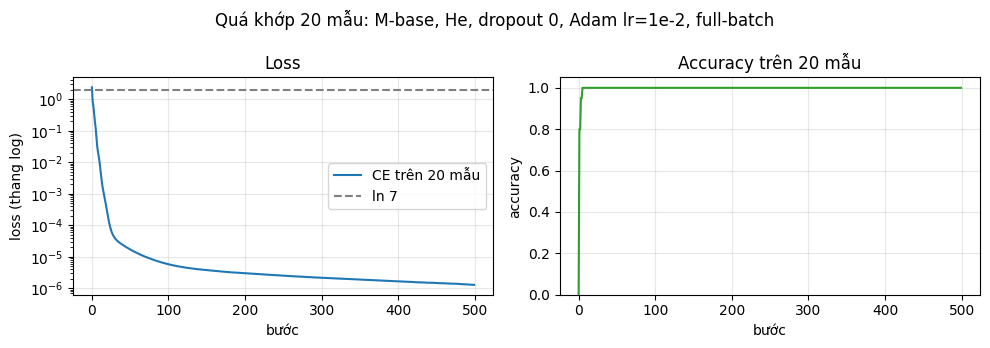

In [7]:
# 1c-2. Quá khớp 20 mẫu: tắt dropout, Adam lr=1e-2, 500 bước full-batch -> loss phải về gần 0
set_seed(42)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
idx = torch.randperm(len(data["X_tr"]), generator=torch.Generator().manual_seed(0))[:20].to(device)
xb, yb = data["X_tr"][idx], data["y_tr"][idx]
opt = torch.optim.Adam(tiny.parameters(), lr=1e-2)
tiny_losses, tiny_accs = [], []
for step in range(500):
    tiny.train()
    opt.zero_grad()
    logits = tiny(xb)
    loss = F.cross_entropy(logits, yb)
    loss.backward()
    opt.step()
    tiny_losses.append(loss.item())                                   # loss trước bước cập nhật này
    tiny_accs.append((logits.argmax(1) == yb).float().mean().item())
first100 = next(k for k, a in enumerate(tiny_accs) if a == 1.0)
tiny.eval()
with torch.no_grad():
    acc20 = (tiny(xb).argmax(1) == yb).float().mean().item()
print(f"loss bước 0 = {tiny_losses[0]:.4f}, loss cuối = {tiny_losses[-1]:.2e}, accuracy trên 20 mẫu = {acc20:.2f}")
print("nhãn của 20 mẫu:", torch.bincount(yb, minlength=7).tolist(), f"| đạt 100% từ bước {first100}")
assert tiny_losses[-1] < 1e-2 and acc20 == 1.0

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.semilogy(tiny_losses, label="CE trên 20 mẫu")
ax1.axhline(math.log(7), ls="--", c="gray", label="ln 7")
ax1.set_xlabel("bước"); ax1.set_ylabel("loss (thang log)"); ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(tiny_accs, c="C2")
ax2.set_xlabel("bước"); ax2.set_ylabel("accuracy"); ax2.set_ylim(0, 1.05); ax2.set_title("Accuracy trên 20 mẫu"); ax2.grid(alpha=0.3)
fig.suptitle("Quá khớp 20 mẫu: M-base, He, dropout 0, Adam lr=1e-2, full-batch")
fig.tight_layout()
plt.show()

In [8]:
# 1d. Gradient có chảy tới mọi tham số? (một lần backward trên một lô val, model mới khởi tạo)
model.train()
model.zero_grad()
F.cross_entropy(model(data["X_val"][:512]), data["y_val"][:512]).backward()
names = ["W1", "b1", "W2", "b2", "W3", "b3"]
for name, (pname, p) in zip(names, model.named_parameters()):
    assert p.grad is not None and p.grad.norm().item() > 0, f"{name} không có gradient"
    print(f"{name} ({pname:<12s}) shape {str(tuple(p.shape)):<11s} ‖grad‖ = {p.grad.norm().item():.4e}")
model.zero_grad()

W1 (net.0.weight) shape (256, 54)   ‖grad‖ = 5.7034e-01
b1 (net.0.bias  ) shape (256,)      ‖grad‖ = 3.7935e-01
W2 (net.2.weight) shape (128, 256)  ‖grad‖ = 2.3436e+00
b2 (net.2.bias  ) shape (128,)      ‖grad‖ = 4.9254e-01
W3 (net.4.weight) shape (7, 128)    ‖grad‖ = 2.0775e+00
b3 (net.4.bias  ) shape (7,)        ‖grad‖ = 5.9524e-01


**Nhận xét Part 1:**
- **Cấu trúc:** M-base có đúng 47 879 tham số; ba Linear (54→256, 256→128, 128→7) đều có bias, lớp cuối ra logit thô, không có softmax, BatchNorm hay LayerNorm. Một lô (8, 54) cho logits (8, 7). M-wide (161 287) và M-deep (55 687) cũng khớp bảng. Khi q > 0, Dropout chỉ nằm ngay sau ReLU của hai lớp ẩn.
- **Khởi tạo He đã được áp dụng thật:** std(W) đo được 0,194 / 0,088 / 0,130, khớp sqrt(2/n_in) = 0,193 / 0,088 / 0,125, và khác xa mức mặc định của `nn.Linear` (≈ 0,079 / 0,036 / 0,051). Bias đều bằng 0.
- **Loss bước 0 trên val = 2,378, cao hơn ln 7 = 1,946 khoảng 0,43.** ln 7 chỉ đúng khi mọi logit gần bằng nhau (softmax đều). Với He, lớp cuối cũng có Var(W3) = 2/128, nên logit có std ≈ 0,65 chứ không ≈ 0. Hơn nữa, vì các kích hoạt sau ReLU luôn ≥ 0 và có trung bình dương, W3·h tạo ra một độ lệch **chung cho mọi mẫu** (trung bình logit theo lớp từ −0,42 đến +0,94). Kết quả là ở bước 0 model đoán lớp 4 (Aspen, chỉ 1,6% dữ liệu) cho 68% số mẫu, nên CE cao hơn mức "đoán đều". Phép đối chứng xác nhận nguyên nhân: thu nhỏ logit 100 lần cho loss 1,948 ≈ ln 7. Đây là hệ quả của cách khởi tạo, không phải lỗi dữ liệu hay nhãn (chuẩn hoá đã kiểm tra ở Part 0). Baseline vẫn giữ He theo quy định; chủ đề *khởi tạo* ở Part 3 sẽ so sánh trực tiếp (ví dụ `normal` std 0,01 cho logit gần 0, nên loss bước 0 sẽ ≈ ln 7).
- **Quá khớp 20 mẫu:** với Adam lr = 1e-2, full-batch, dropout 0, accuracy trên 20 mẫu đạt 100% từ bước 5, loss giảm từ 2,37 xuống 1,3e-6 sau 500 bước. Như vậy nhãn, logit → CE, `zero_grad` và danh sách tham số truyền cho optimizer đều đúng. Phép thử này chỉ cho thấy model *đủ năng lực và vòng cập nhật hoạt động*, chưa nói gì về khả năng tổng quát hoá.
- **Gradient:** sau một lần `backward()`, cả 6 tham số W1, b1, W2, b2, W3, b3 đều có gradient khác None và khác 0 (‖grad‖ từ 0,38 đến 2,34), nên không có lớp nào bị "đứt" gradient.

*(Các số trên đo ở seed 42. Nếu chạy trên GPU mà số lẻ cuối lệch chút ít thì cập nhật theo output của ô bên trên.)*

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [9]:
# Hàm dùng chung cho mọi thí nghiệm: chạy -> lưu JSON -> lưu ảnh -> in tóm tắt.
# REUSE_SAVED = True: nếu results/<exp_id>.json đã có (ví dụ sau khi Colab ngắt kết nối) thì nạp lại thay vì chạy lại.
# Kết quả nạp lại KHÔNG có best_state, nên cấu hình dùng cho đánh giá eval cuối cùng luôn được chạy lại (Part 4).
REUSE_SAVED = False
RESULTS = {}

def run(cfg, reuse=None):
    reuse = REUSE_SAVED if reuse is None else reuse
    path = f"{OUT_DIR}/results/{cfg['exp_id']}.json"
    if reuse and os.path.exists(path):
        r = json.load(open(path, encoding="utf-8")); r["best_state"] = None
        tag = "(nạp lại)"
    else:
        t0 = time.time()
        r = run_experiment(cfg, data)
        save_result(r, f"{OUT_DIR}/results")
        plot_run(r, f"{OUT_DIR}/figures/{cfg['exp_id']}.png")
        tag = f"({time.time() - t0:.0f}s)"
    RESULTS[cfg["exp_id"]] = r
    s = r["summary"]
    if s["best_epoch"] is None:
        print(f"{cfg['exp_id']:<22s} DIVERGED ngay epoch {s['epochs_run']} {tag}")
    else:
        print(f"{cfg['exp_id']:<22s} step0 {s['step0_loss']:.3f} | best ep {s['best_epoch']:>2d} | val loss {s['best_val_loss']:.4f}"
              f" | acc {s['val_acc']:.4f} | macro-F1 {s['val_macro_f1']:.4f} | train loss cuối {s['final_train_loss']:.4f}"
              f" | {s['time_per_epoch_s']:.2f}s/ep{' | DIVERGED' if s['diverged'] else ''} {tag}")
    return r

def summary_table(ids):
    rows = []
    for i in ids:
        r = RESULTS[i]; c, s = r["cfg"], r["summary"]
        rows.append({"exp_id": i, "lr": c["lr"], "seed": c["seed"], "best_epoch": s["best_epoch"],
                     "best_val_loss": s["best_val_loss"], "val_acc": s["val_acc"], "val_macro_f1": s["val_macro_f1"],
                     "final_train_loss": s["final_train_loss"], "final_val_loss": s["final_val_loss"],
                     "grad_norm_ep1": r["history"]["grad_norm"][0], "diverged": s["diverged"]})
    return pd.DataFrame(rows).set_index("exp_id").round(4)

### 2a. Dò learning rate cho baseline (chỉ bằng val)
Giữ nguyên mọi yếu tố của baseline (M-base, He, CE, SGD + momentum 0,9, batch 512, 20 epoch, không dropout/clip, FP32, seed 1), **chỉ đổi lr**.
Lưới lr cách nhau khoảng 3 lần và rộng hơn khoảng gợi ý 0,01–0,1 của GUIDE ở cả hai phía, để thấy cả lr quá nhỏ (học chậm) lẫn lr quá lớn (dao động hoặc phân kỳ).
**Quy tắc chọn (đặt trước khi chạy):** chọn lr có **val macro-F1 cao nhất tại best epoch** (chỉ số chính của lab), trong số các lần chạy không phân kỳ.

**Dự đoán trước:** lr = 0,003 học chậm, sau 20 epoch còn xa hội tụ. lr = 0,3 với momentum 0,9 (bước hiệu dụng ≈ lr/(1−μ) = 3) có thể dao động hoặc phân kỳ. lr tốt nhất nằm trong 0,03–0,1, và đường cong vẫn còn đi xuống ở epoch 20 (GUIDE ghi các cấu hình 20 epoch chưa hội tụ hẳn).

In [10]:
LR_GRID = [0.003, 0.01, 0.03, 0.1, 0.3]
lr_ids = []
for lr in LR_GRID:
    exp_id = f"hp-lr{lr:g}"
    run({**DEFAULT_CFG, "exp_id": exp_id, "group": "hparam", "lr": lr, "seed": 1,
         "description": f"Baseline, chỉ đổi lr = {lr:g} (dò lr cho baseline bằng val)"})
    lr_ids.append(exp_id)

lr_table = summary_table(lr_ids)
display(lr_table)
ok = lr_table[~lr_table["diverged"]]
BASE_LR = float(ok["val_macro_f1"].idxmax().removeprefix("hp-lr"))
print(f"\n==> lr chọn cho baseline (val macro-F1 cao nhất): {BASE_LR:g}")
plot_compare([RESULTS[i] for i in lr_ids], ["train_loss", "val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_lr.png", "Baseline SGD+momentum: dò learning rate (seed 1)")

hp-lr0.003             step0 2.269 | best ep 20 | val loss 0.4198 | acc 0.8250 | macro-F1 0.6647 | train loss cuối 0.4136 | 1.38s/ep (29s)
hp-lr0.01              step0 2.269 | best ep 20 | val loss 0.3110 | acc 0.8747 | macro-F1 0.7613 | train loss cuối 0.2994 | 1.35s/ep (28s)
hp-lr0.03              step0 2.269 | best ep 20 | val loss 0.2660 | acc 0.8921 | macro-F1 0.8170 | train loss cuối 0.2473 | 1.36s/ep (28s)
hp-lr0.1               step0 2.269 | best ep 18 | val loss 0.2379 | acc 0.9054 | macro-F1 0.8390 | train loss cuối 0.2218 | 1.37s/ep (28s)
hp-lr0.3               step0 2.269 | best ep 19 | val loss 0.2318 | acc 0.9090 | macro-F1 0.8573 | train loss cuối 0.2057 | 1.34s/ep (28s)


,lr,seed,best_epoch,best_val_loss,val_acc,val_macro_f1,final_train_loss,final_val_loss,grad_norm_ep1,diverged
exp_id,,,,,,,,,,
hp-lr0.003,0.003,1,20,0.4198,0.8250,0.6647,0.4136,0.4198,0.4266,False
hp-lr0.01,0.010,1,20,0.3110,0.8747,0.7613,0.2994,0.3110,0.4368,False
hp-lr0.03,0.030,1,20,0.2660,0.8921,0.8170,0.2473,0.2660,0.5165,False
hp-lr0.1,0.100,1,18,0.2379,0.9054,0.8390,0.2218,0.2426,0.5296,False
hp-lr0.3,0.300,1,19,0.2318,0.9090,0.8573,0.2057,0.2339,0.3787,False



==> lr chọn cho baseline (val macro-F1 cao nhất): 0.3


### 2b. Baseline với 3 seed: đo độ nhiễu
Cấu hình baseline là `DEFAULT_CFG` với `lr = BASE_LR` vừa chọn. Chạy 3 seed huấn luyện (1, 2, 3); seed thay đổi khởi tạo và thứ tự xáo lô, còn **phép tách val giữ nguyên seed 42**.
`base-s1` trùng cấu hình với lần dò lr tương ứng; chạy lại để kiểm tra tính tái lập (kết quả phải trùng).
Ngưỡng nhiễu theo GUIDE: chênh lệch nhỏ hơn **2σ** (σ là độ lệch chuẩn mẫu giữa các seed) chưa được coi là bằng chứng.

In [11]:
cfg = {**DEFAULT_CFG, "lr": BASE_LR}          # cấu hình baseline; mọi thí nghiệm Part 3 xuất phát từ đây
SEEDS = [1, 2, 3]
base_ids = []
for s in SEEDS:
    run({**cfg, "exp_id": f"base-s{s}", "group": "baseline", "seed": s,
         "description": f"Baseline M-base, SGD+momentum lr={BASE_LR:g}, seed {s}"})
    base_ids.append(f"base-s{s}")

base_table = summary_table(base_ids)
display(base_table)
same = RESULTS["base-s1"]["summary"]["val_macro_f1"] == RESULTS[f"hp-lr{BASE_LR:g}"]["summary"]["val_macro_f1"]
print("base-s1 tái lập đúng lần dò lr cùng cấu hình:", same)

# Độ nhiễu giữa các seed: trung bình ± độ lệch chuẩn mẫu (ddof=1); ngưỡng 2σ dùng cho mọi so sánh ở Part 3
NOISE = {}
for m in ["val_macro_f1", "val_acc", "best_val_loss"]:
    v = base_table[m].astype(float).to_numpy()
    NOISE[m] = {"mean": v.mean(), "std": v.std(ddof=1), "2sigma": 2 * v.std(ddof=1)}
    print(f"{m:<13s}: {v.mean():.4f} ± {v.std(ddof=1):.4f}   (2σ = {2 * v.std(ddof=1):.4f}, min {v.min():.4f}, max {v.max():.4f})")
BASE_F1 = NOISE["val_macro_f1"]["mean"]

plot_compare([RESULTS[i] for i in base_ids], ["train_loss", "val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_baseline_seeds.png", f"Baseline (lr={BASE_LR:g}): 3 seed")

# Phân bố grad_norm của baseline: cơ sở để chọn ngưỡng clip ở Part 3
gn = np.array([RESULTS[i]["history"]["grad_norm"] for i in base_ids])
gmax = np.array([RESULTS[i]["history"]["grad_norm_max"] for i in base_ids])
print(f"\ngrad_norm baseline: trung bình theo epoch từ {gn.min():.3f} đến {gn.max():.3f}; lớn nhất mọi bước = {gmax.max():.3f}")

base-s1                step0 2.269 | best ep 19 | val loss 0.2318 | acc 0.9090 | macro-F1 0.8573 | train loss cuối 0.2057 | 1.37s/ep (28s)
base-s2                step0 1.978 | best ep 16 | val loss 0.2145 | acc 0.9144 | macro-F1 0.8618 | train loss cuối 0.1964 | 1.37s/ep (28s)
base-s3                step0 1.901 | best ep 18 | val loss 0.2208 | acc 0.9121 | macro-F1 0.8630 | train loss cuối 0.2087 | 1.35s/ep (28s)


,lr,seed,best_epoch,best_val_loss,val_acc,val_macro_f1,final_train_loss,final_val_loss,grad_norm_ep1,diverged
exp_id,,,,,,,,,,
base-s1,0.3,1,19,0.2318,0.9090,0.8573,0.2057,0.2339,0.3787,False
base-s2,0.3,2,16,0.2145,0.9144,0.8618,0.1964,0.2251,0.3800,False
base-s3,0.3,3,18,0.2208,0.9121,0.8630,0.2087,0.2337,0.3760,False


base-s1 tái lập đúng lần dò lr cùng cấu hình: True
val_macro_f1 : 0.8607 ± 0.0030   (2σ = 0.0060, min 0.8573, max 0.8630)
val_acc      : 0.9118 ± 0.0027   (2σ = 0.0054, min 0.9090, max 0.9144)
best_val_loss: 0.2224 ± 0.0088   (2σ = 0.0175, min 0.2145, max 0.2318)

grad_norm baseline: trung bình theo epoch từ 0.332 đến 0.380; lớn nhất mọi bước = 4.141


In [12]:
# Colab: đẩy figures/ và results/ lên GitHub để không mất khi runtime ngắt (máy local: git pull). Bỏ comment khi cần.
# push_outputs("Part 2: dò lr và baseline 3 seed")

**Nhận xét baseline** (số từ lần chạy trên Colab, Tesla T4):
- **lr đã chọn: 0,3** (`hp-lr0.3`, val macro-F1 0,8573 tại best epoch 19). Macro-F1 tăng đều theo lr: 0,003 → 0,6647; 0,01 → 0,7613; 0,03 → 0,8170; 0,1 → 0,8390; 0,3 → 0,8573. Mức tăng từ 0,1 lên 0,3 là 0,018, lớn hơn 2σ_seed = 0,006 (đo ở bên dưới). Tuy vậy, lần dò lr chỉ dùng **một seed**, và khi mình chạy thử trên CPU (khác phần cứng nên khác số lẻ), 0,1 và 0,3 gần như ngang nhau (0,8588 so với 0,8566). Vì thế kết luận chắc chắn được là "lr ≥ 0,1 tốt hơn rõ rệt các lr nhỏ"; còn thứ tự giữa 0,1 và 0,3 chỉ là kết quả của seed 1.
- **lr nhỏ học chậm:** với lr 0,003, sau 20 epoch val loss vẫn còn 0,42 và đang giảm (best epoch 20). Mỗi bước cập nhật ngắn nên 14 540 bước không đủ để đi xa, giống triệu chứng "chưa khớp vì thiếu thời gian" trong bảng chẩn đoán. **Khác dự đoán:** mình đoán lr 0,3 (bước hiệu dụng lr/(1−μ) = 3) sẽ dao động hoặc phân kỳ, nhưng nó không phân kỳ và cho kết quả tốt nhất. Với mạng nhỏ, đầu vào đã chuẩn hoá và ‖g‖ nhỏ (≈ 0,38 ở epoch 1), bước này vẫn nằm trong vùng ổn định. Muốn thấy phân kỳ thật (để làm thí nghiệm clipping) phải tăng lr cao hơn nữa.
- **Hình dạng đường cong** (`figures/base-s1.png`, `compare_baseline_seeds.png`): train loss và val loss giảm nhanh trong vài epoch đầu rồi chậm dần. Best epoch là 16–19 ở cả 3 seed, và val loss cuối luôn cao hơn val loss tốt nhất một chút (`base-s1`: 0,2339 so với 0,2318; `base-s2`: 0,2251 so với 0,2145). Nghĩa là ở cuối, val loss **dao động quanh một mức gần phẳng** chứ không còn giảm đều; đây là nhiễu của SGD với lr lớn và không có lịch giảm lr. Khoảng cách val − train ở epoch 20 khoảng 0,03 (0,2339 so với 0,2057), nhỏ so với mức loss, nên **chưa quá khớp rõ rệt**. Mô hình đang ở gần giới hạn của cấu hình này: giảm lr dần (scheduler) hoặc tăng năng lực mạng có thể còn cải thiện; dropout chưa chắc giúp.
- **So với mốc đoán đa số:** val acc 0,912 so với 0,4876, và val macro-F1 0,861 so với ≈ 0,094. Mô hình học được cả các lớp hiếm chứ không chỉ đoán lớp đông nhất. Macro-F1 thấp hơn accuracy khoảng 0,05 cho thấy các lớp nhỏ (3, 4, 5) vẫn khó hơn (phân tích theo lớp ở Part 4).
- **Độ nhiễu seed** (`base-s1/s2/s3`, cùng phép tách val seed 42): val macro-F1 = **0,8607 ± 0,0030 (2σ = 0,0060)**; val acc = 0,9118 ± 0,0027 (2σ = 0,0054); best val loss = 0,2224 ± 0,0088 (2σ = 0,0175). Ở Part 3, một cấu hình chỉ được coi là khác baseline khi **chênh val macro-F1 > 0,006**. Với chỉ 3 seed, ước lượng σ còn rất thô (bản thân σ có thể sai lệch vài chục phần trăm), nên các chênh lệch sát ngưỡng sẽ được nêu là "chưa kết luận được". `base-s1` cho đúng kết quả của `hp-lr0.3`, nên pipeline tái lập được khi giữ nguyên seed.
- **grad_norm** của baseline (trước clip): trung bình theo epoch ổn định trong khoảng **0,33–0,38**, nhưng bước lớn nhất có gai tới **4,14**. Như vậy phần lớn các bước có ‖g‖ < 1, chỉ vài bước nhảy vọt. Ngưỡng c = 1,0 sẽ chỉ cắt các gai này, còn c ≈ 0,3 sẽ cắt khoảng một nửa số bước. Đây là cơ sở để chọn c ở Part 3. *Quan sát thêm (chưa kiểm chứng):* lr 0,3 có ‖g‖ ở epoch 1 nhỏ hơn lr 0,03–0,1 (0,38 so với ~0,52); một giả thuyết là lr lớn đưa mô hình sang vùng loss phẳng hơn.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố so với baseline → chạy → **đối chiếu**. Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

**Quy ước chung**
- Baseline: `cfg` ở Part 2 (M-base, He, CE, SGD + momentum 0,9, **lr = 0,3**, batch 512, 20 epoch, không dropout/clip, FP32). Mọi thí nghiệm dùng **seed 1**, cùng phép tách val (seed 42), cùng 20 epoch; trừ chính yếu tố đang thử.
- Khi phải đổi thêm yếu tố (ví dụ đổi lr cho phù hợp loss/optimizer mới), lý do ghi trong `notes` của cấu hình (và trong bảng xlsx).
- So sánh bằng **val macro-F1 tại best epoch**, Δ tính so với **trung bình 3 seed baseline** (giống công thức của bảng xlsx). Chênh lệch chỉ được coi là có thật khi |Δ| > **2σ_seed = 0,006**; ngoài ra xem thêm val loss, tốc độ hội tụ (`compare_*.png`), khoảng cách val − train, grad_norm.
- Mọi thí nghiệm chạy 1 seed, nên Δ của từng thí nghiệm cũng mang nhiễu cỡ σ; các Δ sát ngưỡng sẽ được nêu là chưa kết luận được.

In [ ]:
STEPS_PER_EPOCH = {b: math.ceil(len(data["X_tr"]) / b) for b in (128, 512, 2048)}
F1_2SIGMA = NOISE["val_macro_f1"]["2sigma"]

def E(exp_id, group, description, notes="", **changes):
    """Cấu hình thí nghiệm = baseline + các thay đổi (seed 1 trừ khi đổi)."""
    return {**cfg, "seed": 1, "exp_id": exp_id, "group": group, "description": description, "notes": notes, **changes}

def compare_table(ids):
    rows = []
    for i in ids:
        r = RESULTS[i]; c, s, h = r["cfg"], r["summary"], r["history"]
        f1 = s["val_macro_f1"]
        d = None if f1 is None else f1 - BASE_F1
        rows.append({
            "exp_id": i, "best_ep": s["best_epoch"], "best_val_loss": s["best_val_loss"],
            "val_acc": s["val_acc"], "val_F1": f1, "ΔF1_vs_base": d,
            "vượt_2σ": "—" if d is None else ("Có" if abs(d) > F1_2SIGMA else "Không"),
            "val−train_cuối": (s["final_val_loss"] - s["final_train_loss"]) if s["final_val_loss"] is not None else None,
            "g_tb": float(np.nanmean(h["grad_norm"])), "g_max": float(np.nanmax(h["grad_norm_max"])),
            "clip_%": 100 * float(np.mean(h["clip_frac"])), "s/ep": s["time_per_epoch_s"],
            "số_bước": s["epochs_run"] * STEPS_PER_EPOCH.get(c["batch"], math.ceil(len(data["X_tr"]) / c["batch"])),
            "peak_MB": s["peak_mem_MB"], "diverged": s["diverged"]})
    df = pd.DataFrame(rows).set_index("exp_id")
    display(df.round(4))
    return df

print(f"baseline: val macro-F1 = {BASE_F1:.4f} (trung bình 3 seed), 2σ = {F1_2SIGMA:.4f}")

### 3.1 Hàm mất mát — `loss-mse-lr0.3`, `loss-mse-lr1`
**Câu hỏi:** thay cross-entropy bằng MSE giữa logit và one-hot (đúng `nn.MSELoss` mặc định: không có 1/2, trung bình trên B·7 phần tử) thì mô hình học tốt hay kém hơn?

**Dự đoán trước:** MSE sẽ **kém hơn rõ** về macro-F1 (Δ âm, vượt 2σ). Lý do:
1. Gradient của MSE theo logit là 2(z − onehot)/(B·7). Hệ số 1/7 làm gradient nhỏ hơn CE nhiều lần, nên cùng lr = 0,3 MSE học chậm hơn.
2. MSE "phạt" cả việc logit của lớp đúng vượt quá 1, và coi 7 đầu ra như 7 bài hồi quy độc lập. Nó không có cơ chế của softmax-CE, nơi gradient (p − y) luôn đẩy lớp đúng lên và các lớp sai xuống cho tới khi dự đoán đúng. Với lớp hiếm, mô hình dễ kéo logit về gần 0 cho mọi mẫu, nên recall của lớp hiếm thấp và macro-F1 tụt mạnh hơn accuracy.

Chạy thêm lr = 1,0 để bù phần gradient nhỏ (so sánh ở lr tốt hơn của MSE, ghi rõ trong `notes`). Hai loss khác thang đo nên **không so giá trị loss**, chỉ so accuracy, macro-F1 và tốc độ tăng macro-F1 theo epoch.

In [ ]:
loss_ids = []
for lr in [0.3, 1.0]:
    e = E(f"loss-mse-lr{lr:g}", "loss", f"MSE (logit vs one-hot, mean trên B·7) thay CE, lr={lr:g}",
          notes="" if lr == 0.3 else "đổi thêm lr=1.0 vì gradient MSE nhỏ hơn CE ~7 lần; so ở lr tốt nhất của MSE",
          loss="mse", lr=lr)
    run(e); loss_ids.append(e["exp_id"])
compare_table(["base-s1"] + loss_ids)
plot_compare([RESULTS[i] for i in ["base-s1"] + loss_ids], ["val_acc", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_loss.png", "CE (base-s1) vs MSE — so bằng metric, không so loss")

**Đối chiếu 3.1:** *(điền sau khi chạy)*

### 3.2 Bộ tối ưu hoá — `opt-sgd-*`, `opt-adam-*`, `opt-adamw-*` (SGD + momentum lấy từ `hp-lr*` ở Part 2)
**Câu hỏi:** ở **lr tốt nhất của mỗi bộ**, SGD, SGD + momentum, Adam, AdamW khác nhau thế nào về chất lượng và tốc độ hội tụ?

Cấu hình: SGD không momentum; SGD + momentum μ = 0,9 (5 lr ở Part 2); Adam và AdamW với betas = (0,9; 0,999), eps = 1e-8; Adam weight_decay = 0; AdamW weight_decay = 0,01. Mỗi bộ thử ≥ 2 lr cách nhau ~3 lần: SGD {0,3; 1; 3} (không momentum thì bước hiệu dụng nhỏ hơn 10 lần so với momentum 0,9, nên cần lr lớn hơn); Adam {3e-4; 1e-3; 3e-3}; AdamW {1e-3; 3e-3}.

**Dự đoán trước:**
- Adam/AdamW tăng macro-F1 **nhanh hơn ở vài epoch đầu**, vì bước được chia theo √v̂ của từng tham số nên các trọng số ít khi nhận gradient (cột one-hot hiếm của Soil_Type) vẫn được cập nhật đủ lớn.
- Sau 20 epoch, ở lr tốt nhất, khoảng cách giữa các bộ sẽ nhỏ (có thể dưới 2σ).
- SGD thuần ở lr = 0,3 kém hơn SGD + momentum ở lr = 0,3, nhưng ở lr = 3 (bước hiệu dụng gần bằng SGDM lr 0,3) sẽ gần bằng.
- AdamW với wd = 0,01 gần như bằng Adam: tổng mức co trọng số chỉ khoảng lr·λ·số bước = 1e-3·0,01·14 540 ≈ 0,15.

In [ ]:
OPT_GRID = {"sgd": [0.3, 1.0, 3.0], "adam": [3e-4, 1e-3, 3e-3], "adamw": [1e-3, 3e-3]}
opt_ids = {"sgd_momentum": lr_ids}                       # SGD + momentum: 5 lr đã chạy ở Part 2
for name, lrs in OPT_GRID.items():
    opt_ids[name] = []
    for lr in lrs:
        wd = 0.01 if name == "adamw" else 0.0
        e = E(f"opt-{name}-lr{lr:g}", "optimizer", f"{name} thay SGD+momentum, lr={lr:g}, wd={wd:g}",
              notes={"sgd": "momentum=0", "adam": "betas=(0.9,0.999), eps=1e-8, wd=0",
                     "adamw": "betas=(0.9,0.999), eps=1e-8, wd=0.01 (tách riêng)"}[name],
              optimizer=name, lr=lr, weight_decay=wd)
        run(e); opt_ids[name].append(e["exp_id"])

all_opt = [i for ids in opt_ids.values() for i in ids]
df_opt = compare_table(all_opt)
best_per_opt = {name: df_opt.loc[ids, "val_F1"].astype(float).idxmax() for name, ids in opt_ids.items()}
print("lr tốt nhất của mỗi bộ tối ưu (theo val macro-F1):", best_per_opt)
plot_compare([RESULTS[i] for i in best_per_opt.values()], ["train_loss", "val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_optimizer.png", "Bộ tối ưu ở lr tốt nhất của mỗi bộ (seed 1)")

**Đối chiếu 3.2:** *(điền sau khi chạy)*

### 3.3 Hyper-parameter — batch size, độ rộng, độ sâu, số epoch, lịch lr
(Dò lr của baseline ở Part 2 cũng thuộc chủ đề này: `hp-lr*`, ảnh `compare_lr.png`.)

**a) Batch size** — `hp-batch128`, `hp-batch2048`, `hp-batch2048-lr1.2`. Cùng 20 epoch nhưng **số bước cập nhật khác nhau**: 128 → 2 906 bước/epoch, 512 → 727, 2048 → 182.
*Dự đoán:* batch 128 (gấp 4 lần số bước, gradient nhiễu hơn) cho val loss thấp hơn hoặc ngang baseline nhưng **chậm hơn ~3–4 lần mỗi epoch**. Batch 2048 với cùng lr chỉ có 1/4 số bước nên **kém hơn rõ** (chưa khớp). Theo quy tắc tỉ lệ tuyến tính (lô ×4 thì lr ×4 = 1,2), số bước bù lại được phần nào. Nhưng lr = 1,2 mà không có khởi động (warm-up) có thể gây gai gradient ở đầu, giống phép thử lr = 1 ở mục clipping, nên kết quả khó đoán. (`hp-batch2048-lr1.2` đổi 2 yếu tố, đã ghi trong notes.)

**b) Kiến trúc** — `hp-wide` (M-wide 54→512→256→7, 161 287 tham số), `hp-deep` (M-deep 54→256→128→64→7, 55 687 tham số).
*Dự đoán:* baseline đang **chưa khớp** (val − train nhỏ, val loss còn giảm), nên tăng năng lực sẽ giúp: M-wide tốt hơn baseline vượt 2σ; M-deep tăng ít hơn (chỉ thêm 7 808 tham số).

**c) Số epoch / lịch lr** — `hp-ep40` (40 epoch), `hp-cosine` (lr giảm theo cosin từ 0,3 về 0 trong 20 epoch).
*Dự đoán:* 40 epoch tốt hơn vì đường cong 20 epoch chưa phẳng hẳn. Cosine giảm biên độ dao động của val loss ở cuối (đã thấy ở baseline) nên cho val loss thấp hơn mà không tốn thêm bước.

In [ ]:
hp_runs = [
    E("hp-batch128", "hparam", "batch 128 thay 512 (cùng lr, 4x số bước)", batch=128),
    E("hp-batch2048", "hparam", "batch 2048 thay 512 (cùng lr, 1/4 số bước)", batch=2048),
    E("hp-batch2048-lr1.2", "hparam", "batch 2048 và lr x4 = 1.2 (quy tắc tỉ lệ tuyến tính, không warm-up)",
      notes="đổi 2 yếu tố: batch và lr (theo quy tắc lô xk thì lr xk)", batch=2048, lr=1.2),
    E("hp-wide", "hparam", "M-wide 54-512-256-7 (161 287 tham số)", hidden=(512, 256)),
    E("hp-deep", "hparam", "M-deep 54-256-128-64-7 (55 687 tham số)", hidden=(256, 128, 64)),
    E("hp-ep40", "hparam", "40 epoch thay 20", epochs=40),
    E("hp-cosine", "hparam", "lịch lr cosine từ 0.3 về 0 trong 20 epoch",
      notes="scheduler=cosine (CosineAnnealingLR, cập nhật mỗi bước, eta_min=0)", scheduler="cosine"),
]
for e in hp_runs:
    run(e)
hp_ids = [e["exp_id"] for e in hp_runs]
compare_table(["base-s1"] + hp_ids)
plot_compare([RESULTS[i] for i in ["base-s1", "hp-batch128", "hp-batch2048", "hp-batch2048-lr1.2"]],
             ["train_loss", "val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_batch.png",
             "Batch size (cùng 20 epoch => số bước khác nhau)")
plot_compare([RESULTS[i] for i in ["base-s1", "hp-wide", "hp-deep"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_arch.png", "Độ rộng / độ sâu")
plot_compare([RESULTS[i] for i in ["base-s1", "hp-ep40", "hp-cosine"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_schedule.png", "Số epoch và lịch lr")

**Đối chiếu 3.3:** *(điền sau khi chạy)*

### 3.4 Dropout — `drop-0.1`, `drop-0.3`
**Câu hỏi:** dropout có giúp khi mô hình **chưa quá khớp** không? Ở baseline, val − train loss ở epoch 20 chỉ khoảng 0,03 và best epoch rơi vào 16–19, tức chưa có dấu hiệu quá khớp rõ.

**Dự đoán trước:** dropout là "thuốc" cho quá khớp, mà baseline thì đang chưa khớp, nên dropout sẽ **không giúp, thậm chí làm kém đi**: q = 0,1 xấp xỉ baseline (|Δ| < 2σ), q = 0,3 kém hơn vượt 2σ. Khoảng cách val − train (đo ở eval mode) sẽ nhỏ lại hoặc âm, vì dropout cản mô hình khớp dữ liệu train. Train loss ở eval mode sẽ cao hơn baseline, tức đúng là chưa khớp, chứ không phải chỉ do lúc huấn luyện bị tắt nơ-ron.

In [ ]:
drop_ids = []
for q in [0.1, 0.3]:
    e = E(f"drop-{q:g}", "dropout", f"dropout q={q:g} sau mỗi ReLU ẩn", dropout=q)
    run(e); drop_ids.append(e["exp_id"])
compare_table(["base-s1"] + drop_ids)
plot_compare([RESULTS[i] for i in ["base-s1"] + drop_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_dropout.png", "Dropout (train loss đo ở eval mode)")

**Đối chiếu 3.4:** *(điền sau khi chạy)*

### 3.5 Cắt gradient — `clip-1-lr0.3`, `clip-none-lr1` / `clip-1-lr1`, `clip-none-lr2` / `clip-1-lr2`
`g ← g · min(1, c/‖g‖)`, với ‖g‖ là chuẩn L2 toàn cục, dùng `clip_grad_norm_`; `grad_norm` luôn ghi **trước** khi cắt.

**Chọn c từ grad_norm baseline:** ở baseline, ‖g‖ trung bình theo epoch là 0,33–0,38 nhưng có gai tới 4,14. Chọn **c = 1,0**: lớn hơn ~2,5 lần mức thường nên hầu hết các bước không bị đụng tới, nhưng cắt được các gai. Cột `clip_%` trong bảng cho biết tỉ lệ bước thực sự bị cắt.

**Phép thử phản chứng ở lr cao:** một phép thử nhanh (4 epoch) cho thấy lr = 1 và lr = 2 không ra NaN, nhưng ở epoch 1 có gai ‖g‖ từ ~12 đến ~80. Ở lr = 2, sau gai đó mạng **"chết"** (chỉ còn đoán lớp đa số). Vì vậy so sánh có clip và không clip **ở cùng lr cao**.

**Dự đoán trước:**
- Ở lr baseline 0,3: clip c = 1 chỉ kích hoạt ở < 1% số bước nên **không khác baseline** (|Δ| < 2σ).
- Ở lr = 1 và 2: không clip thì một bước gai đẩy trọng số ra xa và làm nhiều ReLU chết, nên macro-F1 thấp (lr = 2 có thể kẹt ở mức đoán đa số ≈ 0,094 mà `diverged` vẫn là False, vì loss không phải NaN). Có clip thì độ dài bước bị chặn ở lr·c, mạng sống sót và macro-F1 cao hơn hẳn.

In [ ]:
clip_runs = [
    E("clip-1-lr0.3", "clipping", "clip c=1.0 ở lr baseline 0.3", clip_norm=1.0),
    E("clip-none-lr1", "clipping", "lr=1.0, không clip (đối chứng cho clip ở lr cao)",
      notes="đổi lr để tạo tình huống gradient lớn; so với clip-1-lr1", lr=1.0),
    E("clip-1-lr1", "clipping", "lr=1.0, clip c=1.0", notes="lr cao + clip; so với clip-none-lr1", lr=1.0, clip_norm=1.0),
    E("clip-none-lr2", "clipping", "lr=2.0, không clip (đối chứng)", notes="đổi lr; so với clip-1-lr2", lr=2.0),
    E("clip-1-lr2", "clipping", "lr=2.0, clip c=1.0", notes="lr cao + clip; so với clip-none-lr2", lr=2.0, clip_norm=1.0),
]
for e in clip_runs:
    run(e)
clip_ids = [e["exp_id"] for e in clip_runs]
compare_table(["base-s1"] + clip_ids)
for i in clip_ids:
    h = RESULTS[i]["history"]
    print(f"{i:<15s} ‖g‖ lớn nhất theo epoch (5 epoch đầu): {np.round(h['grad_norm_max'][:5], 2)} | % bước bị cắt: {np.round(100 * np.array(h['clip_frac'][:5]), 2)}")
plot_compare([RESULTS[i] for i in ["base-s1"] + clip_ids], ["val_macro_f1", "grad_norm", "grad_norm_max"],
             f"{OUT_DIR}/figures/compare_clipping.png", "Clipping c=1 ở lr baseline và ở lr cao (grad_norm đo trước clip)")

**Đối chiếu 3.5:** *(điền sau khi chạy)*

### 3.6 Mixed precision — `amp-fp16`, `amp-bf16`, `amp-fp16-wide`
FP16: `autocast(float16)` + `GradScaler` (nhân loss với hệ số s trước backward để gradient nhỏ không bị làm tròn về 0; `unscale_` trước khi đo/clip gradient). BF16: `autocast(bfloat16)`, không cần GradScaler. Tham số vẫn là FP32; đánh giá luôn ở FP32.

Vì sao FP16 cần s còn BF16 thì không: FP16 có 5 bit mũ, số dương nhỏ nhất khoảng 6e-8 (subnormal) và lớn nhất 65 504, nên gradient nhỏ dễ **underflow** về 0. BF16 có 8 bit mũ giống FP32 (khoảng ~1e-38 đến ~3e38), chỉ kém về độ chính xác (7 bit phần định trị), nên không bị underflow và không cần nhân hệ số.

**Dự đoán trước:**
- Metric của FP16 và BF16 ≈ FP32 (|Δ| < 2σ).
- Với M-base (47k tham số, lô 512), thời gian mỗi epoch bị chi phối bởi chi phí gọi kernel và vòng Python (727 bước/epoch), nên AMP **không nhanh hơn**, có thể chậm hơn vì thêm bước ép kiểu và GradScaler.
- Bộ nhớ đỉnh gần như không đổi, vì phần lớn là dữ liệu đã nằm sẵn trên GPU (`peak_MB`).
- T4 (compute capability 7.5) có Tensor Core FP16 nhưng **không có BF16 phần cứng**, nên BF16 có thể chậm hơn.
- `amp-fp16-wide` (so với `hp-wide`, cùng M-wide FP32) kiểm tra xem khi phép nhân ma trận lớn hơn thì FP16 có bắt đầu nhanh hơn không.

In [ ]:
amp_ids = []
if device.type == "cuda":
    cap = torch.cuda.get_device_capability()
    print(f"GPU {torch.cuda.get_device_name(0)}, compute capability {cap}; BF16 phần cứng: {cap >= (8, 0)}; "
          f"torch.cuda.is_bf16_supported() = {torch.cuda.is_bf16_supported()}")
    amp_runs = [
        E("amp-fp16", "amp", "FP16 autocast + GradScaler", precision="fp16"),
        E("amp-bf16", "amp", "BF16 autocast (không GradScaler)", precision="bf16",
          notes="" if cap >= (8, 0) else f"GPU compute capability {cap} không có BF16 phần cứng (giả lập)"),
        E("amp-fp16-wide", "amp", "FP16 trên M-wide (so với hp-wide FP32)",
          notes="đổi 2 yếu tố so với baseline (hidden=512-256, fp16); so với hp-wide", hidden=(512, 256), precision="fp16"),
    ]
    for e in amp_runs:
        run(e)
    amp_ids = [e["exp_id"] for e in amp_runs]
    df_amp = compare_table(["base-s1", "amp-fp16", "amp-bf16", "hp-wide", "amp-fp16-wide"])
    for i in amp_ids:
        print(f"{i:<14s} số bước bị GradScaler bỏ qua (gradient inf/NaN): {RESULTS[i]['summary']['skipped_steps']}")
    plot_compare([RESULTS[i] for i in ["base-s1", "amp-fp16", "amp-bf16", "hp-wide", "amp-fp16-wide"]],
                 ["val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_amp.png",
                 "FP32 vs FP16 vs BF16 (M-base) và FP32 vs FP16 (M-wide)")
else:
    print("Không có GPU CUDA: bỏ qua thí nghiệm mixed precision (ghi lý do vào báo cáo).")

**Đối chiếu 3.6:** *(điền sau khi chạy)*

### 3.7 Khởi tạo tham số — `init-zeros`, `init-normal`, `init-xavier`, `init-default`
Bias = 0 với mọi cách (trừ `default`, giữ nguyên mặc định của `nn.Linear`). `xavier` dùng `xavier_normal_` với Var = 2/(n_vào + n_ra) (không phải 1/n_vào như slide). `normal` là N(0; 0,01²). `default` là mặc định của PyTorch: U(±1/√n_vào) cho cả W và b, tức Var = 1/(3·n_vào).
Độ lệch chuẩn kích hoạt đo **sau mỗi ReLU** (và của logit), trên một lô val 4 096 mẫu ở bước 0.

**Dự đoán trước cho `zeros`:** mọi W = 0 nên h₁ = ReLU(0) = 0, h₂ = 0, logit = b₃ = 0, và loss bước 0 = ln 7 *đúng tuyệt đối*. Gradient của W₃ = δ·h₂ᵀ = 0, của W₂ và W₁ cũng bằng 0 (lan truyền ngược nhân với W₃ = 0 và W₂ = 0, cộng với ReLU'(0) = 0). **Chỉ b₃ có gradient.** Các nơ-ron trong cùng một lớp hoàn toàn đối xứng và không bao giờ thoát ra được, nên mạng chỉ học được *tần suất lớp* qua b₃: luôn đoán lớp đa số, acc ≈ 0,4876, macro-F1 ≈ 0,094, loss kẹt ở entropy của phân phối lớp (≈ 1,2).
**Dự đoán cho các cách khác:** `normal` (std 0,01) cho kích hoạt co lại sau mỗi lớp (std nhỏ hơn ~10 lần mỗi lớp), logit ≈ 0 nên loss bước 0 ≈ ln 7; mạng 3 lớp vẫn học được nhưng chậm hơn ở vài epoch đầu. `xavier` và `default` có std kích hoạt nhỏ hơn He (vì Var nhỏ hơn 2/n_vào) nhưng không suy biến; với chỉ 3 lớp, kết quả sau 20 epoch có lẽ gần He (|Δ| < 2σ). Khác biệt rõ chỉ xuất hiện ở mạng sâu (ô đối chiếu với mạng 30 lớp bên dưới).

In [ ]:
# Ở bước 0 (chưa huấn luyện): std kích hoạt sau mỗi ReLU, loss bước 0, chuẩn gradient từng lớp sau 1 backward
xb0, yb0 = data["X_val"][:4096], data["y_val"][:4096]
rows = []
for init in ["he", "xavier", "default", "normal", "zeros"]:
    set_seed(1)
    m = MLP(hidden=(256, 128), init=init).to(device)
    st = activation_stats(m, xb0)
    m.train(); m.zero_grad()
    loss = F.cross_entropy(m(xb0), yb0); loss.backward()
    g = {n: p.grad.norm().item() for n, p in m.named_parameters()}
    rows.append({"init": init, "std_ReLU1": st[0], "std_ReLU2": st[1], "std_logit": st[2], "loss_bước0": loss.item(),
                 "‖∇W1‖": g["net.0.weight"], "‖∇W2‖": g["net.2.weight"], "‖∇W3‖": g["net.4.weight"],
                 "‖∇b1‖": g["net.0.bias"], "‖∇b3‖": g["net.4.bias"]})
display(pd.DataFrame(rows).set_index("init").round(5))

# Mạng sâu 30 lớp ẩn 256 (chỉ forward, không huấn luyện) để so với biểu đồ "30 lớp ReLU" của slide
deep_rows = []
for init in ["he", "xavier", "default", "normal"]:
    set_seed(1)
    st = activation_stats(MLP(hidden=(256,) * 30, init=init).to(device), xb0)
    deep_rows.append({"init": init, **{f"lớp {k}": st[k - 1] for k in (1, 5, 10, 20, 30)}})
print("std kích hoạt sau ReLU ở mạng 30 lớp ẩn (bước 0):")
display(pd.DataFrame(deep_rows).set_index("init").map(lambda v: f"{v:.2e}"))

In [ ]:
init_ids = []
for init in ["zeros", "normal", "xavier", "default"]:
    e = E(f"init-{init}", "init", f"khởi tạo {init} thay He", init=init)
    run(e); init_ids.append(e["exp_id"])
compare_table(["base-s1"] + init_ids)
plot_compare([RESULTS[i] for i in ["base-s1"] + init_ids], ["train_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_init.png", "Khởi tạo: he (base-s1) vs zeros / normal / xavier / default")

**Đối chiếu 3.7:** *(điền sau khi chạy)*

In [ ]:
# Colab: đẩy figures/ và results/ của Part 3 lên GitHub (máy local: git pull). Bỏ comment khi cần.
# push_outputs("Part 3: thí nghiệm 7 chủ đề")

### 3.8 Chọn cấu hình cuối cùng (chỉ bằng val)
*(viết sau khi có kết quả 3.1–3.7: chọn các thay đổi có Δ val macro-F1 vượt 2σ, kết hợp, rồi chạy 3 seed để kiểm tra bằng val trước khi sang Part 4)*

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [15]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [16]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [17]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary